In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import photometry.photometry as phot
import photometry.likelihood as L
import deconfuser.sample_planets as sample_planets

plt.rcParams.update({'font.size': 14})

In [3]:
# read in syste params from files
filedir = "/Users/shasler/Code/deconfuser_copy/output_files/ten_systems_for_paper/output_with_rmsErrors/"
true_file = filedir + "true_orbits_for_plotting.csv"
options_file = filedir + "ranked_confused_options_for_plotting.csv"

df_true = pd.read_csv(true_file)
df_confused = pd.read_csv(options_file)
incl_groups = ['low', 'med', 'high']

In [4]:
n_system = 10
# Get the true and confused data for the system of interest
df_true_sys = df_true[df_true['system'] == n_system]
df_confused_sys = df_confused[df_confused['system'] == n_system]
df_confused_sys

,system,n_orbit_options,partition,L_orbit,top_a,top_e,top_i,top_o,top_O,top_M0,ranking,incl_group
60,10,1.0,"[[0, 1, 2], [3, 4, 5], [6, 7, 8]]",5.684094e-02,3.938422,0.065367,0.452237,2.889477,0.499357,-1.175961,0,low
61,10,1.0,"[[0, 1, 2], [3, 4, 5], [6, 7, 8]]",1.761430e-04,1.599195,0.029449,0.439241,-2.483057,0.885865,1.178581,0,low
62,10,1.0,"[[0, 1, 2], [3, 4, 5], [6, 7, 8]]",1.482790e-04,0.537494,0.025000,0.487686,2.514673,-2.185315,-11.114004,0,low
63,10,1.0,"[[0, 1, 2], [3, 5, 7], [4, 6, 8]]",6.708067e-02,3.938422,0.065367,0.452237,2.889477,0.499357,-1.175961,1,low
64,10,1.0,"[[0, 1, 2], [3, 5, 7], [4, 6, 8]]",3.587540e-04,1.394329,0.099381,1.375060,1.617819,-0.413455,-0.972754,1,low
65,10,1.0,"[[0, 1, 2], [3, 5, 7], [4, 6, 8]]",7.923600e-10,6.020223,0.097057,1.590427,-4.660366,-1.837336,2.750414,1,low
129,10,1.0,"[[0, 1, 2], [3, 4, 5], [6, 7, 8]]",3.419334e-03,3.896689,0.084071,1.031655,3.047390,0.784815,-1.555084,0,med
130,10,1.0,"[[0, 1, 2], [3, 4, 5], [6, 7, 8]]",4.972680e-03,1.621812,0.052145,1.048110,-5.384007,-2.327129,0.993909,0,med
131,10,4.0,"[[0, 1, 2], [3, 4, 5], [6, 7, 8]]",1.014976e-03,0.545099,0.082074,1.064217,5.288107,0.866087,-10.736472,0,med
132,10,1.0,"[[0, 1, 2], [3, 5, 7], [4, 6, 8]]",2.473771e-03,3.896689,0.084071,1.031655,3.047390,0.784815,-1.555084,1,med


In [5]:
# Set up planet, star, and detector parameters for photometry
n_planets = 3
mu = 4*np.pi**2
star = phot.Star(T=5778, R_star=695700e3, d_system=10, mu=mu) # system distance in parsecs -- values for the Sun
planet = phot.Planet(R_p=6.371e6, Ag=0.3)                         # values for Earth
detector = phot.Detector(qe=0.837, cic=0.016, dark_current=1.3e-4, read_noise=120, gain=1000, 
                    fwc=80000, conversion_gain=1.0, t=3600, D=2.36, throughput=0.38, f_pa=0.039,
                    wavelength=573.8e-9, bandwidth=56.5e-9) # Roman instrument parameters

cadence = 0.5
n_epochs = 3
ts = cadence * np.arange(n_epochs)

cadence_extra = 0.01
n_epochs_extra = 100
ts_extra = cadence_extra * np.arange(n_epochs_extra)

In [6]:
# Functions for getting true planet parameters
def get_planet_params(df_true_sys, incl_group):
    df_true_inclgroup = df_true_sys[df_true_sys['incl_group'] == incl_group]
    a = df_true_inclgroup['a'].values
    e = df_true_inclgroup['e'].values
    i = df_true_inclgroup['i'].values
    o = df_true_inclgroup['o'].values
    O = df_true_inclgroup['O'].values
    M0 = df_true_inclgroup['M0'].values
    return a, e, i, o, O, M0

def get_detections(a, e, i, o, O, M0, ts, mu):
    # Calculate detections for planet parameters
    xs,ys,zs = sample_planets.get_observations(a, e, i, o, O, M0, ts, mu)
    observations = np.stack([xs,ys,zs], axis=2).reshape((-1,3))

    # Reshhape observations
    all_coords = []
    for ip in range(n_planets):
        all_coords.append(list(map(list, observations[ip*len(ts):(ip+1)*len(ts)])))
    all_coords = np.asarray(all_coords)

    return all_coords

def get_true_fpfs_photrates(n_planets, all_coords, all_coords_extra, planet, star, detector):
    phase_angles, fpfs_true, photrates_true = [], [], []
    phases_all, fpfs_all, photrates_all = [], [], []

    for ip in range(n_planets):
        xyzs_planet = all_coords[ip]
        xyzs_extra_planet = all_coords_extra[ip]

        xs, ys, zs = phot.separate_xyzs(xyzs_planet)
        xs_extra, ys_extra, zs_extra = phot.separate_xyzs(xyzs_extra_planet)

        phases, phase_func, fpfs, photon_rates = phot.get_planet_count_rate(planet, star, detector, xs=xs, ys=ys, zs=zs)
        phases_extra, phase_func_extra, fpfs_extra, photon_rates_extra = phot.get_planet_count_rate(planet, star, detector, xs=xs_extra, ys=ys_extra, zs=zs_extra)

        phase_angles.append(phases)
        fpfs_true.append(fpfs)
        photrates_true.append(photon_rates)
        phases_all.append(phases_extra)
        fpfs_all.append(fpfs_extra)
        photrates_all.append(photon_rates_extra)

    return phase_angles, fpfs_true, photrates_true, phases_all, fpfs_all, photrates_all

##### Get the "observed" detections

In [7]:
# Get true planet parameter for each inclination group in system of interest
a_low, e_low, i_low, o_low, O_low, M0_low = get_planet_params(df_true_sys, incl_group='low')
a_med, e_med, i_med, o_med, O_med, M0_med = get_planet_params(df_true_sys, incl_group='med')
a_high, e_high, i_high, o_high, O_high, M0_high = get_planet_params(df_true_sys, incl_group='high')

# Low i
low_coords = get_detections(a_low, e_low, i_low, o_low, O_low, M0_low, ts, mu)
low_coords_extra = get_detections(a_low, e_low, i_low, o_low, O_low, M0_low, ts_extra, mu)

# Med i
med_coords = get_detections(a_med, e_med, i_med, o_med, O_med, M0_med, ts, mu)
med_coords_extra = get_detections(a_med, e_med, i_med, o_med, O_med, M0_med, ts_extra, mu)

# High i
high_coords = get_detections(a_high, e_high, i_high, o_high, O_high, M0_high, ts, mu)
high_coords_extra = get_detections(a_high, e_high, i_high, o_high, O_high, M0_high, ts_extra, mu)

# "OBSERVATIONS"
# noisy_detections, detections_photon_rates = phot.get_detections_counts(n_planets, n_epochs, xyzs=all_coords, 
#                                                                            Planet=planet, Star=star, Detector=detector)

# noisy_detections_extra, detections_photrates_extra = phot.get_detections_counts(n_planets, 
#                                                                                 n_epochs_extra, 
#                                                                                 xyzs=all_coords_extra,
#                                                                                 Planet=planet, Star=star, 
#                                                                                 Detector=detector)

# Get true phases, fpfs, photon rates, etc
# Low i
phase_angles_low, fpfs_true_low, photrates_true_low, phases_all_low, fpfs_all_low, photrates_all_low = get_true_fpfs_photrates(n_planets, low_coords, 
                                                                                                                               low_coords_extra, planet, 
                                                                                                                               star, detector)
# med i
phase_angles_med, fpfs_true_med, photrates_true_med, phases_all_med, fpfs_all_med, photrates_all_med = get_true_fpfs_photrates(n_planets, med_coords, 
                                                                                                                               med_coords_extra, planet, 
                                                                                                                               star, detector)
# high i
phase_angles_high, fpfs_true_high, photrates_true_high, phases_all_high, fpfs_all_high, photrates_all_high = get_true_fpfs_photrates(n_planets, high_coords, 
                                                                                                                               high_coords_extra, planet, 
                                                                                                                               star, detector)

#### Now get the "expected" measurements given the orbit fits' parameters

In [8]:
def get_confused_params(df_confused_sys, incl_group, which_ranked_option):
    df_confused_inclgroup = df_confused_sys[df_confused_sys['incl_group'] == incl_group]
    df_confused_option = df_confused_inclgroup[df_confused_inclgroup['ranking'] == which_ranked_option]
    
    a = df_confused_option['top_a'].values
    e = df_confused_option['top_e'].values
    i = df_confused_option['top_i'].values
    o = df_confused_option['top_o'].values
    O = df_confused_option['top_O'].values
    M0 = df_confused_option['top_M0'].values
    return a, e, i, o, O, M0

def get_confused_fpfs_photrates(n_planets, a_opt, e_opt, i_opt, o_opt, O_opt, M0_opt, ts, mu, 
                                planet, star, detector):
    
    opt_phases_list = []
    opt_photon_rates_list = []
    opt_fpfs_list = []

    for ip in range(n_planets):
        #  Get detection coordinates 
        xs, ys, zs = sample_planets.get_observations(a_opt[ip], e_opt[ip], i_opt[ip], 
                                                        o_opt[ip], O_opt[ip], M0_opt[ip], 
                                                        ts, mu)
        
        # Calculate phase and intensity information   
        phases, phase_func, fpfs, photon_rates = phot.get_planet_count_rate(planet, star, detector,
                                                                            xs=xs, ys=ys, zs=zs)

        opt_phases_list.append(phases)
        opt_photon_rates_list.append(photon_rates)
        opt_fpfs_list.append(fpfs)

    return opt_phases_list, opt_fpfs_list, opt_photon_rates_list

In [9]:
# Read in orbital parameters of confused options for system of interest per inclination grouping
# Option 1
# Low i
a_opt1_low, e_opt1_low, i_opt1_low, o_opt1_low, O_opt1_low, M0_opt1_low = get_confused_params(df_confused_sys, incl_group='low', which_ranked_option=0)
# Med i
a_opt1_med, e_opt1_med, i_opt1_med, o_opt1_med, O_opt1_med, M0_opt1_med = get_confused_params(df_confused_sys, incl_group='med', which_ranked_option=0)
# High i
a_opt1_high, e_opt1_high, i_opt1_high, o_opt1_high, O_opt1_high, M0_opt1_high = get_confused_params(df_confused_sys, incl_group='high', which_ranked_option=0)

# Get fpfs, photon rates for each planet in each incl grouping in option 1
# Low
opt1_low_phases_list, opt1_low_fpfs_list, opt1_low_photon_rates_list = get_confused_fpfs_photrates(n_planets, a_opt1_low, e_opt1_low, i_opt1_low, o_opt1_low, 
                                                                                                      O_opt1_low, M0_opt1_low, ts, mu, planet, star, detector)
# Med
opt1_med_phases_list, opt1_med_fpfs_list, opt1_med_photon_rates_list = get_confused_fpfs_photrates(n_planets, a_opt1_med, e_opt1_med, i_opt1_med, o_opt1_med, 
                                                                                                      O_opt1_med, M0_opt1_med, ts, mu, planet, star, detector)
# High
opt1_high_phases_list, opt1_high_fpfs_list, opt1_high_photon_rates_list = get_confused_fpfs_photrates(n_planets, a_opt1_high, e_opt1_high, i_opt1_high, o_opt1_high, 
                                                                                                      O_opt1_high, M0_opt1_high, ts, mu, planet, star, detector)

In [10]:
# Option 2
# low i
a_opt2_low, e_opt2_low, i_opt2_low, o_opt2_low, O_opt2_low, M0_opt2_low = get_confused_params(df_confused_sys, incl_group='low', which_ranked_option=1)
# med i
a_opt2_med, e_opt2_med, i_opt2_med, o_opt2_med, O_opt2_med, M0_opt2_med = get_confused_params(df_confused_sys, incl_group='med', which_ranked_option=1)
# high i
a_opt2_high, e_opt2_high, i_opt2_high, o_opt2_high, O_opt2_high, M0_opt2_high = get_confused_params(df_confused_sys, incl_group='high', which_ranked_option=1)

# Get flux ratio, phot rates
# low i
opt2_low_phases_list, opt2_low_fpfs_list, opt2_low_photon_rates_list = get_confused_fpfs_photrates(n_planets, a_opt2_low, e_opt2_low, i_opt2_low, o_opt2_low, 
                                                                                                      O_opt2_low, M0_opt2_low, ts, mu, planet, star, detector)
# med i
opt2_med_phases_list, opt2_med_fpfs_list, opt2_med_photon_rates_list = get_confused_fpfs_photrates(n_planets, a_opt2_med, e_opt2_med, i_opt2_med, o_opt2_med, 
                                                                                                      O_opt2_med, M0_opt2_med, ts, mu, planet, star, detector)
# high i
opt2_high_phases_list, opt2_high_fpfs_list, opt2_high_photon_rates_list = get_confused_fpfs_photrates(n_planets, a_opt2_high, e_opt2_high, i_opt2_high, o_opt2_high, 
                                                                                                      O_opt2_high, M0_opt2_high, ts, mu, planet, star, detector)

### Plotting:

In [ ]:
def plot_fpfs_v_time(ts_extra, ts, fpfs_true_all, fpfs_true, opt1_fpfs_list, opt2_fpfs_list, 
                     save_fig=False, save_path=None, fig_format='pdf', epoch_markers = ['o', 's', 'v'], 
                     plot_legend=True, plot_titles=True):

    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12,4))
    axes = [ax1, ax2, ax3]
    # Plot true full curve 
    ax1.plot(ts_extra, fpfs_true_all[0], lw=1.5, linestyle='dashed', c='k')
    ax2.plot(ts_extra, fpfs_true_all[1], lw=1.5, linestyle='dashed', c='k', label='Truth')
    ax3.plot(ts_extra, fpfs_true_all[2],  lw=1.5, linestyle='dashed', c='k')
    # Plot points corresponding to true detections
    ax1.scatter(ts, fpfs_true[0], color='k', marker='x', zorder=3)
    ax2.scatter(ts, fpfs_true[1], color='k', marker='x', zorder=3)    
    ax3.scatter(ts, fpfs_true[2], color='k', marker='x', zorder=3)

    i = 1
    for ax in axes:
        ax.set_xlabel('Time (yr)')
        if plot_titles:
            ax.set_title(f'Planet {i}')
        i += 1

    # Option A
    for epoch in range(n_epochs):
        ax1.scatter(ts[epoch], opt1_fpfs_list[0][epoch], marker=epoch_markers[epoch], s=65, c='#912F56', edgecolors='k', lw=0.5)
        ax2.scatter(ts[epoch], opt1_fpfs_list[1][epoch], marker=epoch_markers[epoch], s=50, c='#912F56', edgecolors='k', lw=0.5, label='Option A' if epoch==0 else "")
        ax3.scatter(ts[epoch], opt1_fpfs_list[2][epoch], marker=epoch_markers[epoch], s=50, c='#912F56', edgecolors='k', lw=0.5)

        # Option B
        ax1.scatter(ts[epoch], opt2_fpfs_list[0][epoch], marker=epoch_markers[epoch], s=45, alpha=0.8, c='#72D7E1', edgecolors='k', lw=0.5)
        ax2.scatter(ts[epoch], opt2_fpfs_list[1][epoch], marker=epoch_markers[epoch], s=50, c='#72D7E1', edgecolors='k', lw=0.5, label='Option B' if epoch==0 else "")
        ax3.scatter(ts[epoch], opt2_fpfs_list[2][epoch], marker=epoch_markers[epoch], s=50, c='#72D7E1', edgecolors='k', lw=0.5)

    ax1.set_ylabel('F$_p$/F$_s$')
    if plot_legend:
        ax2.legend(framealpha=0.6, bbox_to_anchor=(1.4, -0.25), ncol=3)
    
    # else:
    plt.tight_layout()
    if save_fig:
        plt.savefig(save_path, dpi='figure', bbox_inches='tight', format=fig_format)
        plt.savefig(save_path.replace(f'.{fig_format}', '.png'), dpi='figure', bbox_inches='tight', format='png')
    plt.show()

def plot_fpfs_v_phase(phases_all, phases_detected, ts, fpfs_true_all, fpfs_true_epochs, opt1_phases, opt1_fpfs, 
                      opt2_phases, opt2_fpfs, save_fig=False, save_path=None, fig_format='pdf', epoch_markers = ['o', 's', 'v']):

    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12,4))
    axes = [ax1, ax2, ax3]
    ax1.scatter(phases_all[0], fpfs_true_all[0], s=4, c='k')
    ax2.scatter(phases_all[1], fpfs_true_all[1], s=4, c='k')
    ax3.scatter(phases_all[2], fpfs_true_all[2], s=4, c='k')

    ax1.scatter(phases_detected[0], fpfs_true_epochs[0], color='k', marker='x',s=50, zorder=3)
    ax2.scatter(phases_detected[1], fpfs_true_epochs[1], color='k', marker='x',s=50, zorder=3, label='Truth')    
    ax3.scatter(phases_detected[2], fpfs_true_epochs[2], color='k', marker='x',s=50, zorder=3)

    # Option A
    for epoch in range(n_epochs):
        ax1.scatter(opt1_phases[0][epoch], opt1_fpfs[0][epoch], marker=epoch_markers[epoch],  s=65, edgecolors='k', lw=0.5, c='#912F56')
        ax2.scatter(opt1_phases[1][epoch], opt1_fpfs[1][epoch], marker=epoch_markers[epoch], s=50, edgecolors='k', lw=0.5, c='#912F56', 
                    label='Option A' if epoch==0 else "")
        ax3.scatter(opt1_phases[2][epoch], opt1_fpfs[2][epoch], marker=epoch_markers[epoch], s=50, edgecolors='k', lw=0.5, c='#912F56')
        
    # Option B
        ax1.scatter(opt2_phases[0][epoch], opt2_fpfs[0][epoch], marker=epoch_markers[epoch], s=45, alpha=0.8, c='#72D7E1')
        ax2.scatter(opt2_phases[1][epoch], opt2_fpfs[1][epoch], marker=epoch_markers[epoch], s=50, c='#72D7E1', edgecolors='k', lw=0.5, 
                    label='Option B' if epoch==0 else "")
        ax3.scatter(opt2_phases[2][epoch], opt2_fpfs[2][epoch], marker=epoch_markers[epoch], s=50, c='#72D7E1', edgecolors='k', lw=0.5)

    i = 1
    for ax in axes:
        ax.set_xlabel('Phase angle (°)')
        ax.set_title(f'Planet {i}')
        i += 1
    ax1.set_ylabel('F$_p$/F$_s$')

    ax2.legend()
    plt.tight_layout()
    if save_fig:
        plt.savefig(save_path, dpi='figure', bbox_inches='tight', format=fig_format)
        plt.savefig(save_path.replace(f'.{fig_format}', '.png'), dpi='figure', bbox_inches='tight', format='png')
    plt.show()

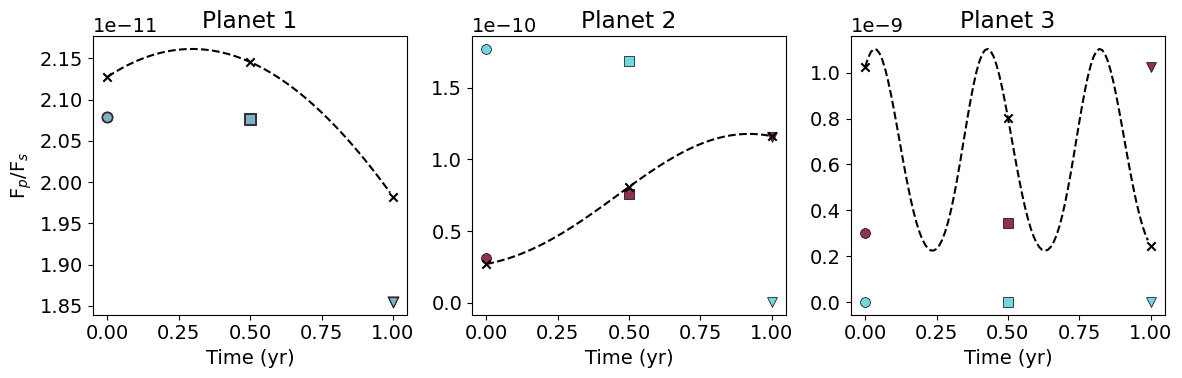

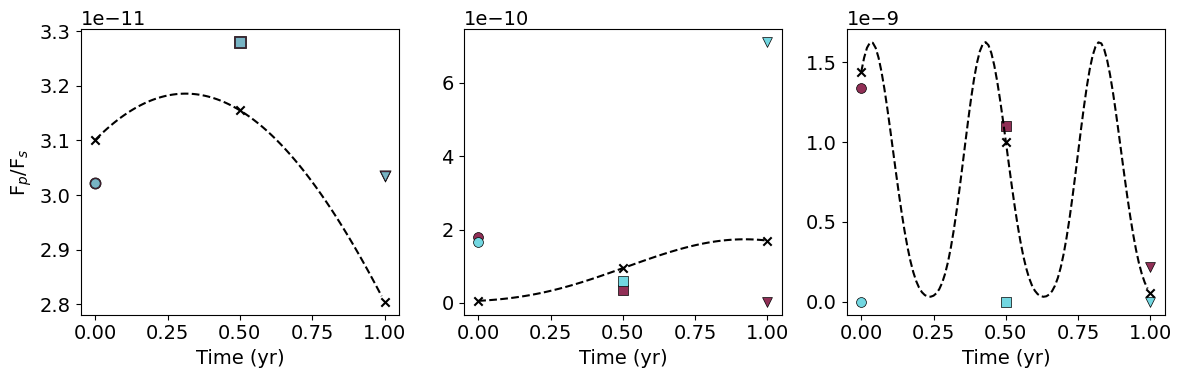

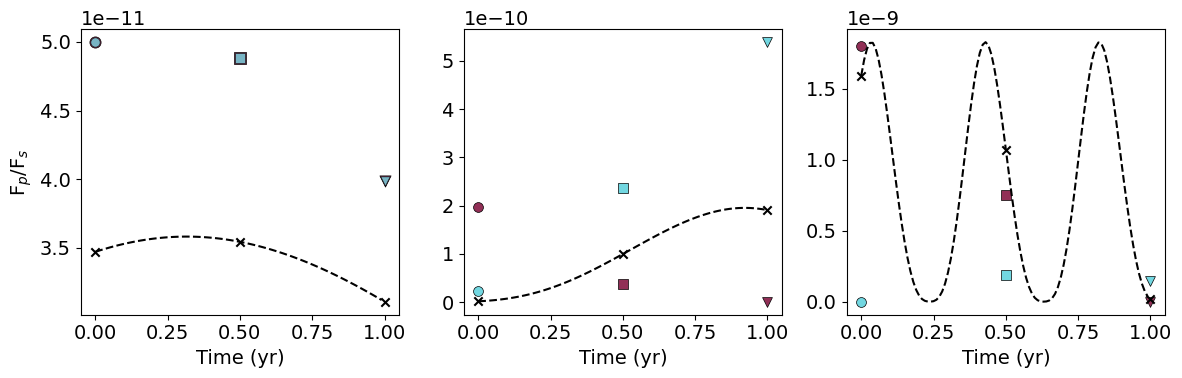

In [48]:
# Low i
plot_fpfs_v_time(ts_extra, ts, fpfs_all_low, fpfs_true_low, opt1_low_fpfs_list, opt2_low_fpfs_list, plot_legend=False, plot_titles=True)
# Med i
plot_fpfs_v_time(ts_extra, ts, fpfs_all_med, fpfs_true_med, opt1_med_fpfs_list, opt2_med_fpfs_list, plot_legend=False, plot_titles=False)
# High i
plot_fpfs_v_time(ts_extra, ts, fpfs_all_high, fpfs_true_high, opt1_high_fpfs_list, opt2_high_fpfs_list, plot_legend=False, plot_titles=False)

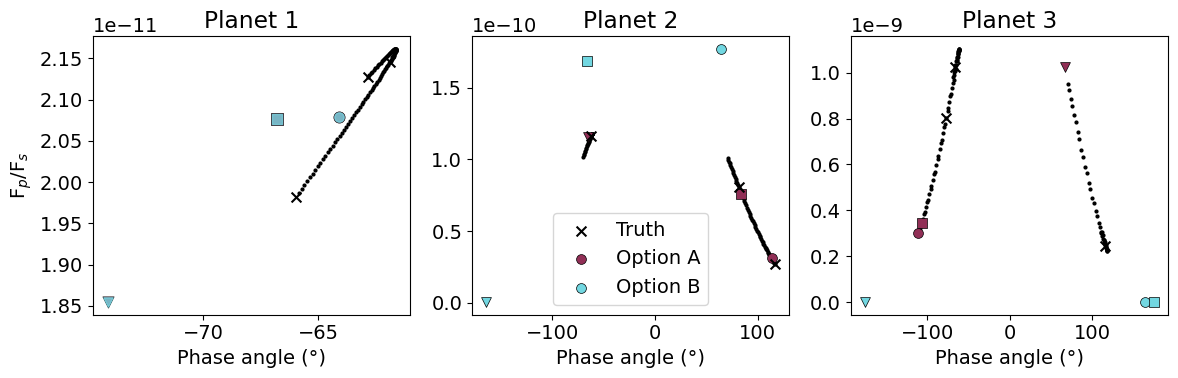

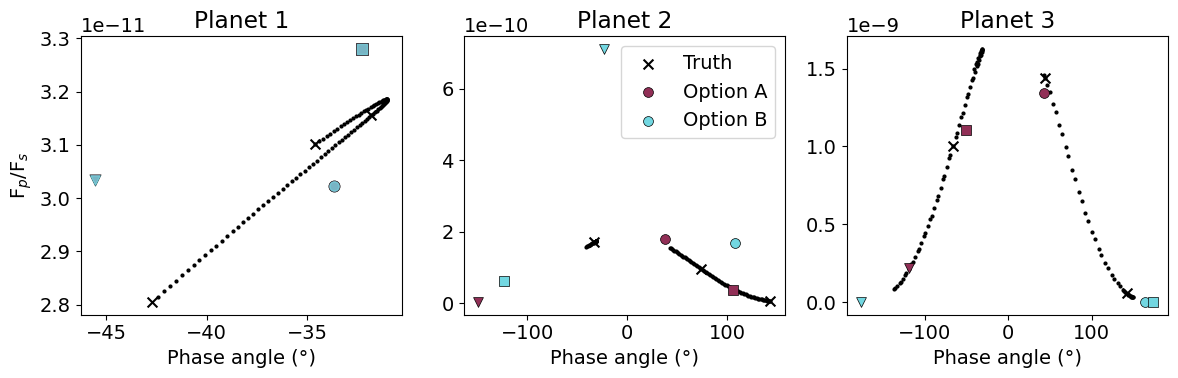

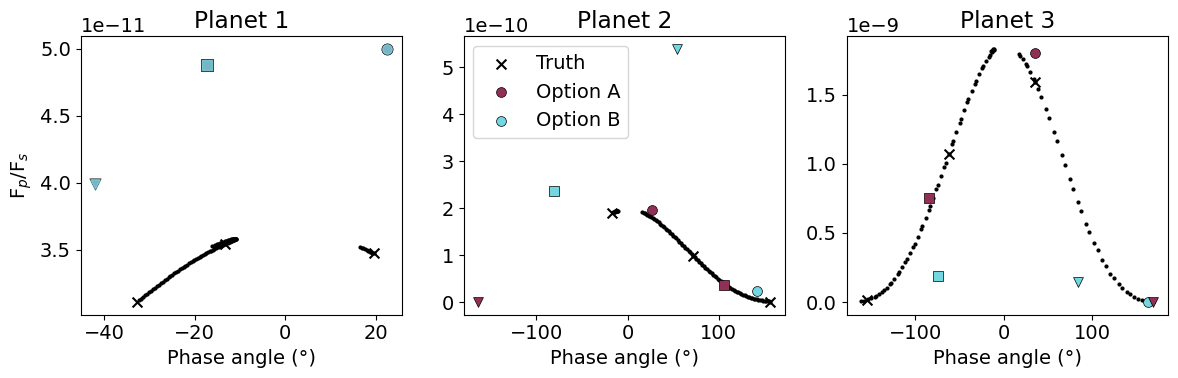

In [16]:
plot_fpfs_v_phase(phases_all_low, phase_angles_low, ts, fpfs_all_low, fpfs_true_low, opt1_low_phases_list, opt1_low_fpfs_list, opt2_low_phases_list, opt2_low_fpfs_list)
plot_fpfs_v_phase(phases_all_med, phase_angles_med, ts, fpfs_all_med, fpfs_true_med, opt1_med_phases_list, opt1_med_fpfs_list, opt2_med_phases_list, opt2_med_fpfs_list)
plot_fpfs_v_phase(phases_all_high, phase_angles_high, ts, fpfs_all_high, fpfs_true_high, opt1_high_phases_list, opt1_high_fpfs_list, opt2_high_phases_list, opt2_high_fpfs_list)